### Import the emhass optimized result

In [2]:
import pandas as pd
optimal_df = pd.read_csv('Battery_opt_res_latest.csv')
#optimal_df.head()

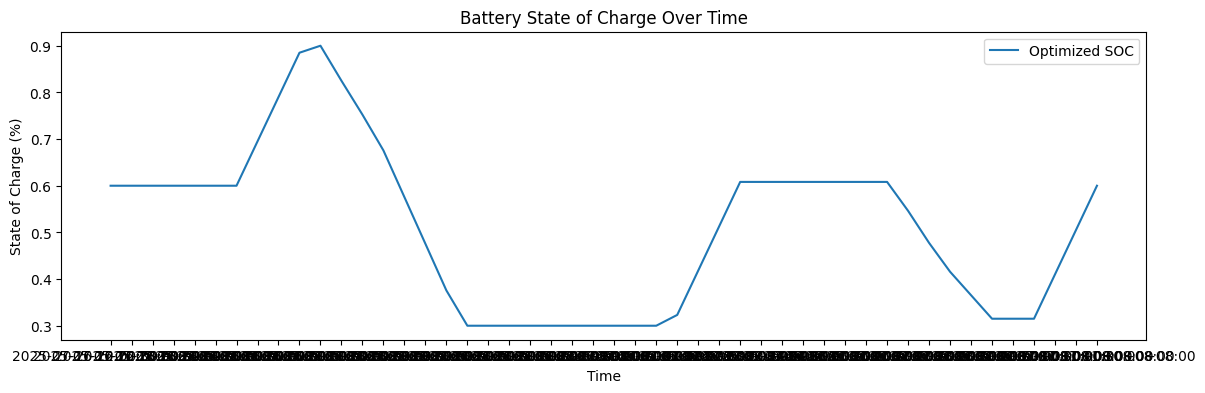

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 4))
plt.plot(optimal_df['timestamp'], optimal_df['SOC_opt'], label='Optimized SOC')
plt.ylabel('State of Charge (%)')
plt.xlabel('Time')
plt.title('Battery State of Charge Over Time')
plt.legend()
plt.show()

In [5]:
interval_hours = 0.5  # adjust for your time step
# Charging: 
energy_charged = (-optimal_df['P_batt'][optimal_df['P_batt'] < 0] * interval_hours).sum() / 1000  # kWh

# Discharging:
energy_discharged = (optimal_df['P_batt'][optimal_df['P_batt'] > 0] * interval_hours).sum() / 1000  # kWh

print('Total energy charged (kWh):', energy_charged)
print('Total energy discharged (kWh):', energy_discharged)

Total energy charged (kWh): 4.7008033849999995
Total energy discharged (kWh): 4.242475055


In [3]:
if 'P_grid_neg' in optimal_df.columns:
    total_prod_revenue = (0.5*optimal_df['unit_prod_price'] * 0.001* (-optimal_df['P_grid_neg'])).sum()
    print('Optimal revenue of a day (unit_prod_price * P_grid_neg):', total_prod_revenue)
else:
    print('P_grid_neg column not found in optimal_df')

for col in ['P_grid_pos']:
    if col not in optimal_df.columns:
        optimal_df[col] = 0  # fallback if missing
if 'unit_load_cost' not in optimal_df.columns:
    optimal_df['unit_load_cost'] = 0.1419  # fallback if not present
total_load_cost = 0.5*(0.001*(optimal_df['P_grid_pos']) * optimal_df['unit_load_cost']).sum()
print('Optimal cost of a day ((P_grid_pos) * unit_load_cost):', total_load_cost)

optimal_cost = total_load_cost - total_prod_revenue
print('Optimal Total cost:', optimal_cost)

Optimal revenue of a day (unit_prod_price * P_grid_neg): 0.0
Optimal cost of a day ((P_grid_pos) * unit_load_cost): 3.7698999126884996
Optimal Total cost: 3.7698999126884996


In [ ]:
columns_to_keep = ['timestamp','P_PV', 'P_Load', 'unit_load_cost', 'unit_prod_price']
df = optimal_df[[col for col in columns_to_keep if col in optimal_df.columns]]

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour for each timestamp
hours = df['timestamp'].dt.hour

# Create deferrable load mask, operate for 1 hour from 19:00 to 20:00.
mask_0 = (hours >= 19) & (hours < 20)

# Assign values
df['P_deferrable0'] = 0
df.loc[mask_0, 'P_deferrable0'] = 1000


C:\Users\26293\AppData\Local\Temp\ipykernel_36460\1174048850.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df['timestamp'])
C:\Users\26293\AppData\Local\Temp\ipykernel_36460\1174048850.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_deferrable0'] = 0


In [5]:
mask1 = (hours >= 6) & (hours < 7)
mask2 = (hours >= 19) & (hours < 20)

# Assign values
df['P_deferrable1'] = 0
df.loc[mask1 | mask2, 'P_deferrable1'] = 2400

C:\Users\26293\AppData\Local\Temp\ipykernel_36460\1820169128.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_deferrable1'] = 0


### Add Deferrable 3, dryer, power = 3000

In [6]:
mask3 = (hours >= 21) & (hours < 22)

# Assign values
df['P_deferrable2'] = 0
df.loc[mask3, 'P_deferrable2'] = 3000

df.head()

C:\Users\26293\AppData\Local\Temp\ipykernel_36460\306167580.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_deferrable2'] = 0


,timestamp,P_PV,P_Load,unit_load_cost,unit_prod_price,P_deferrable0,P_deferrable1,P_deferrable2
0,2025-07-16 12:00:00+08:00,0,564.508740,0.1419,0.1419,0,0,0
1,2025-07-16 12:30:00+08:00,0,386.751777,0.1419,0.1419,0,0,0
2,2025-07-16 13:00:00+08:00,0,694.896835,0.1419,0.1419,0,0,0
3,2025-07-16 13:30:00+08:00,0,569.256123,0.1419,0.1419,0,0,0
4,2025-07-16 14:00:00+08:00,0,461.306806,0.1419,0.1419,0,0,0


In [7]:
# Calculate total usage time (in hours) for each deferrable variable
interval_hours = 0.5  # 30 minutes per row

for col in ['P_deferrable0', 'P_deferrable1', 'P_deferrable2']:
    if col in df.columns:
        usage_time = (df[col] > 0).sum() * interval_hours
        print(f"{col} total usage time (hours):", usage_time)
    else:
        print(f"{col} column not found in df")

P_deferrable0 total usage time (hours): 1.0
P_deferrable1 total usage time (hours): 2.0
P_deferrable2 total usage time (hours): 1.0


In [8]:
# Calculate P_grid
df['P_grid'] = df['P_Load']+ df['P_deferrable0']+ df['P_deferrable1'] + df['P_deferrable2'] - df['P_PV']

df['P_grid_pos'] = df['P_grid'].apply(lambda x: x if x > 0 else 0)
df['P_grid_neg'] = df['P_grid'].apply(lambda x: x if x < 0 else 0)
df.head()

C:\Users\26293\AppData\Local\Temp\ipykernel_36460\746816500.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_grid'] = df['P_Load']+ df['P_deferrable0']+ df['P_deferrable1'] + df['P_deferrable2'] - df['P_PV']
C:\Users\26293\AppData\Local\Temp\ipykernel_36460\746816500.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_grid_pos'] = df['P_grid'].apply(lambda x: x if x > 0 else 0)
C:\Users\26293\AppData\Local\Temp\ipykernel_36460\746816500.py:5: SettingWithCopyWarning: 
A value is trying to be s

,timestamp,P_PV,P_Load,unit_load_cost,unit_prod_price,P_deferrable0,P_deferrable1,P_deferrable2,P_grid,P_grid_pos,P_grid_neg
0,2025-07-16 12:00:00+08:00,0,564.508740,0.1419,0.1419,0,0,0,564.508740,564.508740,0
1,2025-07-16 12:30:00+08:00,0,386.751777,0.1419,0.1419,0,0,0,386.751777,386.751777,0
2,2025-07-16 13:00:00+08:00,0,694.896835,0.1419,0.1419,0,0,0,694.896835,694.896835,0
3,2025-07-16 13:30:00+08:00,0,569.256123,0.1419,0.1419,0,0,0,569.256123,569.256123,0
4,2025-07-16 14:00:00+08:00,0,461.306806,0.1419,0.1419,0,0,0,461.306806,461.306806,0


In [9]:
# Calculate total usage time (in hours) for deferrable 0 and 1
interval_hours = 0.5  # 30 minutes per row

if 'P_deferrable0' in df.columns:
    usage_time_0 = (df['P_deferrable0'] > 0).sum() * interval_hours
    print('P_deferrable0 total usage time (hours):', usage_time_0)
else:
    print('P_deferrable0 column not found in df')

if 'P_deferrable1' in df.columns:
    usage_time_1 = (df['P_deferrable1'] > 0).sum() * interval_hours
    print('P_deferrable1 total usage time (hours):', usage_time_1)
else:
    print('P_deferrable1 column not found in df')

if 'P_deferrable2' in df.columns:
    usage_time_2 = (df['P_deferrable2'] > 0).sum() * interval_hours
    print('P_deferrable2 total usage time (hours):', usage_time_2)
else:
    print('P_deferrable2 column not found in df')

# Revenue and cost calculations using df
if 'P_grid_neg' in df.columns:
    origin_total_prod_revenue = (0.5 * df['unit_prod_price'] * 0.001 * (-df['P_grid_neg'])).sum()
    print('Original revenue of a day (unit_prod_price * P_grid_neg):', origin_total_prod_revenue)
else:
    print('P_grid_neg column not found in df')

for col in ['P_grid_pos']:
    if col not in df.columns:
        df[col] = 0  # fallback if missing
if 'unit_load_cost' not in df.columns:
    df['unit_load_cost'] = 0.1419  # fallback if not present
original_total_load_cost = 0.5 * (0.001 * df['P_grid_pos'] * df['unit_load_cost']).sum()
print('Original cost of a day ((P_grid_pos) * unit_load_cost):', original_total_load_cost)

original_cost = original_total_load_cost - origin_total_prod_revenue
print('Original Total cost:', original_cost)

P_deferrable0 total usage time (hours): 1.0
P_deferrable1 total usage time (hours): 2.0
P_deferrable2 total usage time (hours): 1.0
Original revenue of a day (unit_prod_price * P_grid_neg): 0.0
Original cost of a day ((P_grid_pos) * unit_load_cost): 4.07781590376721
Original Total cost: 4.07781590376721


In [10]:
savings_percent = (original_cost - optimal_cost) / original_cost * 100
print('savings percent:', savings_percent,'%')

savings percent: 7.551002751111153 %


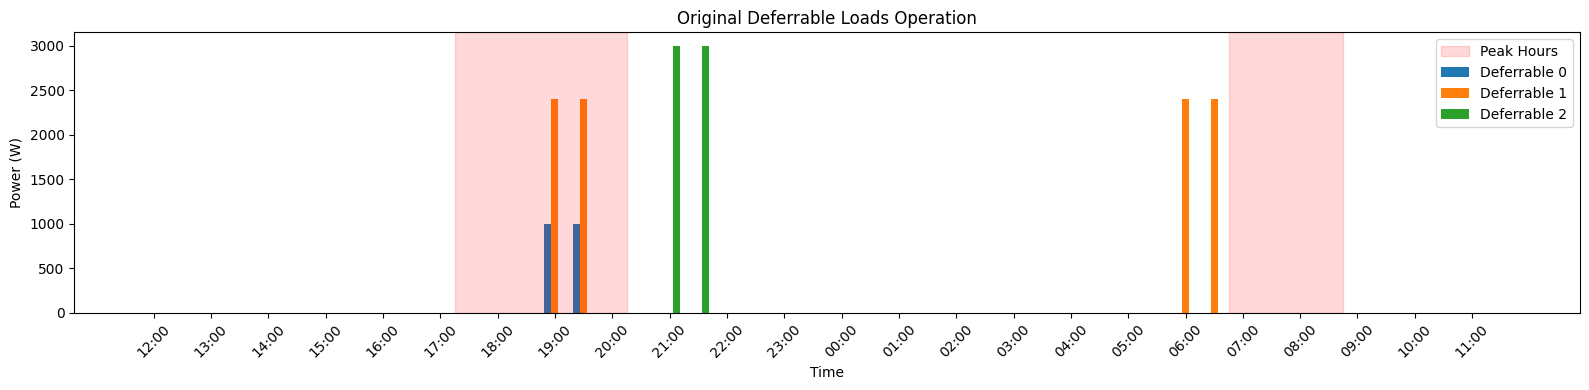

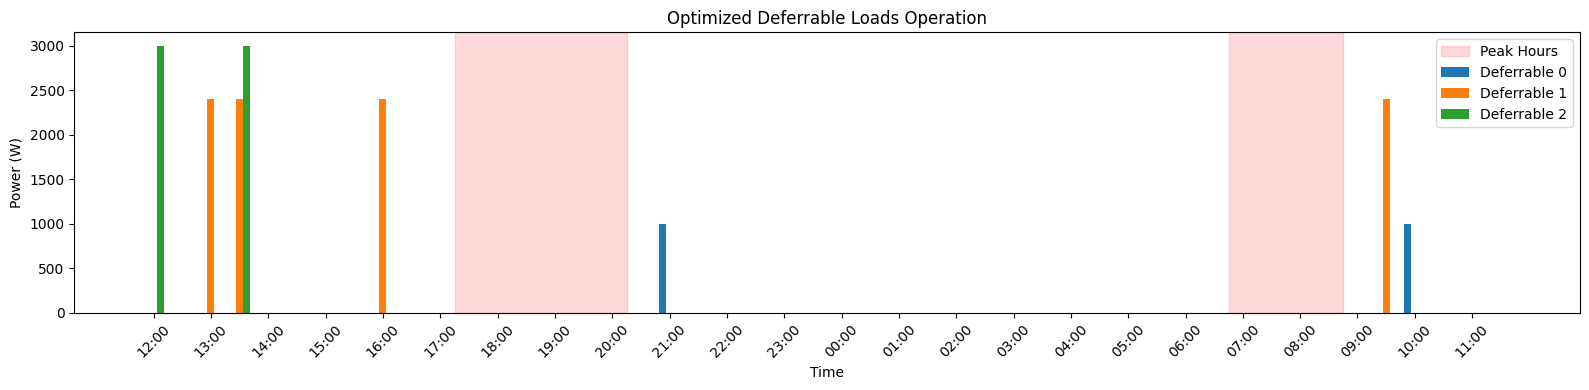

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare time axis
time_axis = pd.to_datetime(df['timestamp'])
time_labels = [t.strftime('%H:%M') for t in time_axis]
x = np.arange(len(time_axis))
bar_width = 0.25

# --- Original schedule ---
plt.figure(figsize=(16, 4))
plt.bar(x - bar_width, df['P_deferrable0'], width=bar_width, label='Deferrable 0')
plt.bar(x, df['P_deferrable1'], width=bar_width, label='Deferrable 1')
plt.bar(x + bar_width, df['P_deferrable2'], width=bar_width, label='Deferrable 2')

# Highlight peak hours: 7–9am and 5:30–8:30pm
for start, end in [(7, 9), (17.5, 20.5)]:
    # Find indices where hour/minute falls in the interval
    indices = [i for i, t in enumerate(time_axis)
               if (t.hour + t.minute/60) >= start and (t.hour + t.minute/60) < end]
    if indices:
        plt.axvspan(indices[0] - 0.5, indices[-1] + 0.5, color='red', alpha=0.15, label='Peak Hours' if start == 7 else None)

plt.title('Original Deferrable Loads Operation')
plt.ylabel('Power (W)')
plt.xlabel('Time')
plt.xticks(ticks=x[::2], labels=[l for i, l in enumerate(time_labels) if i % 2 == 0], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# --- Optimized schedule ---
if 'P_deferrable0' in optimal_df.columns and 'P_deferrable1' in optimal_df.columns and 'P_deferrable2' in optimal_df.columns:
    time_axis_opt = pd.to_datetime(optimal_df['timestamp'])
    time_labels_opt = [t.strftime('%H:%M') for t in time_axis_opt]
    x_opt = np.arange(len(time_axis_opt))
    plt.figure(figsize=(16, 4))
    plt.bar(x_opt - bar_width, optimal_df['P_deferrable0'], width=bar_width, label='Deferrable 0')
    plt.bar(x_opt, optimal_df['P_deferrable1'], width=bar_width, label='Deferrable 1')
    plt.bar(x_opt + bar_width, optimal_df['P_deferrable2'], width=bar_width, label='Deferrable 2')
    
    # Highlight peak hours: 7–9am and 5:30–8:30pm
    for start, end in [(7, 9), (17.5, 20.5)]:
        indices = [i for i, t in enumerate(time_axis_opt)
                   if (t.hour + t.minute/60) >= start and (t.hour + t.minute/60) < end]
        if indices:
            plt.axvspan(indices[0] - 0.5, indices[-1] + 0.5, color='red', alpha=0.15, label='Peak Hours' if start == 7 else None)
    plt.title('Optimized Deferrable Loads Operation')
    plt.ylabel('Power (W)')
    plt.xlabel('Time')
    plt.xticks(ticks=x_opt[::2], labels=[l for i, l in enumerate(time_labels_opt) if i % 2 == 0], rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Optimized schedule columns not found in optimal_df")

In [12]:
# Print out when each deferrable operates after optimization
if all(col in optimal_df.columns for col in ['timestamp', 'P_deferrable0', 'P_deferrable1', 'P_deferrable2']):
    print("Deferrable operation times after optimization:")
    for i, col in enumerate(['P_deferrable0', 'P_deferrable1', 'P_deferrable2']):
        active_times = optimal_df.loc[optimal_df[col] > 0, 'timestamp']
        if not active_times.empty:
            print(f"  {col}:")
            for t in active_times:
                print(f"    {pd.to_datetime(t)}")
        else:
            print(f"  {col}: Not operated")
else:
    print("Required columns for deferrable operation times not found in optimal_df")

Deferrable operation times after optimization:
  P_deferrable0:
    2025-07-16 21:00:00+08:00
    2025-07-17 10:00:00+08:00
  P_deferrable1:
    2025-07-16 13:00:00+08:00
    2025-07-16 13:30:00+08:00
    2025-07-16 16:00:00+08:00
    2025-07-17 09:30:00+08:00
  P_deferrable2:
    2025-07-16 12:00:00+08:00
    2025-07-16 13:30:00+08:00


In [13]:
import plotly.graph_objs as go

labels = ['Savings', 'Remaining Cost']
values = [original_cost - optimal_cost, optimal_cost]
savings_percent = (original_cost - optimal_cost) / original_cost * 100

fig = go.Figure(data=[go.Pie(labels=labels, values=values)])
fig.update_traces(textinfo='label+percent', pull=[0.1, 0], marker=dict(colors=['green', 'orange']))
fig.update_layout(title=f'Cost Savings Percentage: {savings_percent:.2f}%')
fig.show()

In [14]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# optimal_df['timestamp'] = pd.to_datetime(optimal_df['timestamp'])
# optimal_df['hour_decimal'] = optimal_df['timestamp'].dt.hour + optimal_df['timestamp'].dt.minute / 60
# df_corr = pd.DataFrame({
#     'Opt_P_deferrable0': optimal_df['P_deferrable0'],
#     'Opt_P_deferrable1': optimal_df['P_deferrable1'],
#     'P_PV': optimal_df['P_PV'],
#     'P_Load': optimal_df['P_Load'],
#     'time': optimal_df['hour_decimal']
# })

# df_corr.head()
# # Correlation matrix
# corr = df_corr.corr()
# plt.figure(figsize=(7,5))
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation: Optimal Schedule vs PV, Load, Time')
# plt.show()


In [17]:
import matplotlib.pyplot as plt

# Compute original (naive) cost per 30min slot
original_cost_per_slot =  (0.5 * 0.001 * df['P_grid_pos'] * df['unit_load_cost']  # import cost
    - 0.5 * 0.001 * (-df['P_grid_neg']) * df['unit_prod_price']  # export revenue
)
print("Total original (naive) cost:", original_cost_per_slot.sum())
# Get optimized cost per 30min slot
# If cost_fun_selfcons is profit (negative for cost), flip the sign
optimized_cost_per_slot = -optimal_df['cost_fun_profit'] 
print("Total optimal cost:", optimized_cost_per_slot.sum())

Total original (naive) cost: 4.07781590376721
Total optimal cost: 3.769899912688499


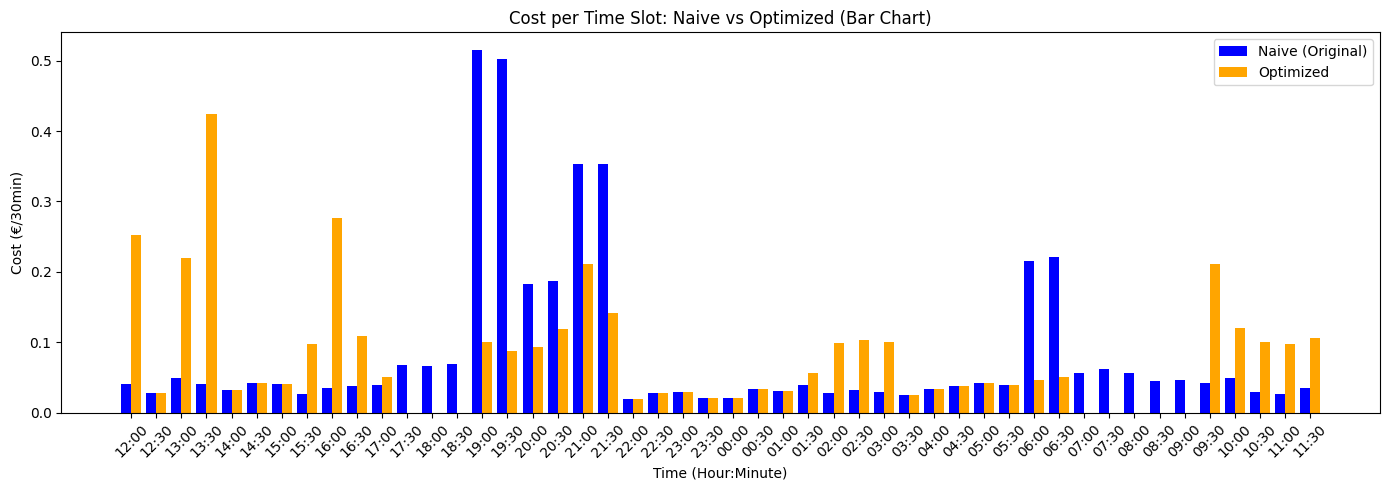

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare time axis (use combined_df['time'] if available, else create a range)
time_axis = pd.to_datetime(df['timestamp'])

# Set up bar width and positions
bar_width = 0.4
x = np.arange(len(time_axis))

plt.figure(figsize=(14, 5))
plt.bar(x - bar_width/2, original_cost_per_slot, width=bar_width, label='Naive (Original)', color='blue')
if optimized_cost_per_slot is not None:
    plt.bar(x + bar_width/2, optimized_cost_per_slot, width=bar_width, label='Optimized', color='orange')

# Set x-ticks to every 0.5 hour (every slot)
plt.xticks(
    ticks=x[::1],  # every slot (0.5h)
    labels=[t.strftime('%H:%M') for t in time_axis][::1],
    rotation=45
)

plt.xlabel('Time (Hour:Minute)')
plt.ylabel('Cost (€/30min)')
plt.title('Cost per Time Slot: Naive vs Optimized (Bar Chart)')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
import plotly.graph_objs as go

# Prepare time axis (use combined_df['time'] if available, else create a range)
time_axis = pd.to_datetime(df['timestamp'])

fig = go.Figure()

# Bar for Naive (Original)
fig.add_trace(go.Bar(
    x=time_axis,
    y=original_cost_per_slot,
    name='Naive (Original)',
    marker_color='blue',
    hovertemplate='Time: %{x|%Y-%m-%d %H:%M}<br>Cost: %{y:.4f} €'
))

# Bar for Optimized
if optimized_cost_per_slot is not None:
    fig.add_trace(go.Bar(
        x=time_axis,
        y=optimized_cost_per_slot,
        name='Optimized',
        marker_color='orange',
        hovertemplate='Time: %{x|%Y-%m-%d %H:%M}<br>Cost: %{y:.4f} €'
    ))

fig.update_layout(
    barmode='group',
    title='Cost per Time Slot: Original vs Optimized (Bar Chart)',
    xaxis_title='Time (Hour)',
    yaxis_title='Cost (€/30min)',
    xaxis=dict(
        tickformat='%H:%M',
        tickangle=45,
        rangeslider_visible=True
    ),
    hovermode='x unified'
)


In [20]:
import plotly.graph_objs as go

interval_hours = 0.5  # 30 minutes per row

# Energy per slot in kWh
original_energy_per_slot = df['P_grid'] * interval_hours / 1000
optimized_energy_per_slot = optimal_df['P_grid'] * interval_hours / 1000

time_axis = pd.to_datetime(df['timestamp'])
if 'timestamp' in optimal_df.columns:
    time_axis_opt = pd.to_datetime(optimal_df['timestamp'])
else:
    time_axis_opt = time_axis

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=time_axis,
    y=original_energy_per_slot,
    mode='lines',
    name='Original Energy per Slot (kWh)',
    line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=time_axis_opt,
    y=optimized_energy_per_slot,
    mode='lines',
    name='Optimized Energy per Slot (kWh)',
    line=dict(color='orange')
))
fig.update_layout(
    title='Energy Usage per Time Slot: Energy from grid (Original vs Optimized)',
    xaxis_title='Time',
    yaxis_title='Energy per Slot (kWh)',
    hovermode='x unified'
)
fig.show()

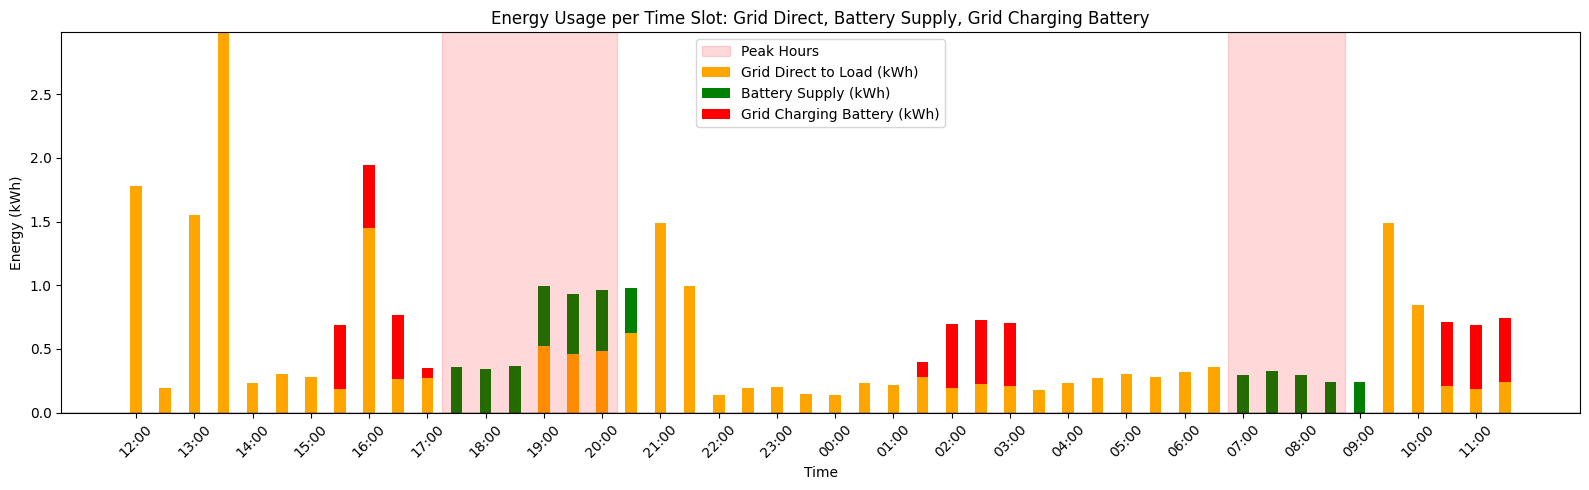

In [6]:
import matplotlib.pyplot as plt
import numpy as np

interval_hours = 0.5  # 30 minutes per row

# Prepare time axis
time_axis = pd.to_datetime(optimal_df['timestamp'])
time_labels = [t.strftime('%H:%M') for t in time_axis]
x = np.arange(len(time_axis))
bar_width = 0.4

# Grid import (kWh, positive)
grid_import = optimal_df['P_grid_pos'] * interval_hours / 1000

# Battery discharge (supplying load/deferrables, kWh)
battery_supply = optimal_df['P_batt'].where(optimal_df['P_batt'] > 0, 0) * interval_hours / 1000

# Grid power used to charge battery (kWh)
grid_charge_batt = -optimal_df['P_batt'].where((optimal_df['P_batt'] < 0) & (optimal_df['P_grid_pos'] > 0), 0) * interval_hours / 1000

plt.figure(figsize=(16, 5))
plt.bar(x, grid_import - grid_charge_batt, width=bar_width, label='Grid Direct to Load (kWh)', color='orange')
plt.bar(x, battery_supply, width=bar_width, bottom=grid_import - grid_charge_batt, label='Battery Supply (kWh)', color='green')
plt.bar(x, grid_charge_batt, width=bar_width, bottom=grid_import - grid_charge_batt + battery_supply, label='Grid Charging Battery (kWh)', color='red')

# Highlight peak hours: 7–9am and 5:30–8:30pm
for start, end in [(7, 9), (17.5, 20.5)]:
    indices = [i for i, t in enumerate(time_axis)
               if (t.hour + t.minute/60) >= start and (t.hour + t.minute/60) < end]
    if indices:
        plt.axvspan(indices[0] - 0.5, indices[-1] + 0.5, color='red', alpha=0.15, label='Peak Hours' if start == 7 else None)

plt.axhline(0, color='black', linewidth=1)
plt.title('Energy Usage per Time Slot: Grid Direct, Battery Supply, Grid Charging Battery')
plt.ylabel('Energy (kWh)')
plt.xlabel('Time')
plt.xticks(ticks=x[::2], labels=[l for i, l in enumerate(time_labels) if i % 2 == 0], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()